In [19]:
IMAGE_ID = 'S1585-2_a'
ROI_X = 4820
ROI_Y = 1710
ROI_W = 128
ROI_H = 256


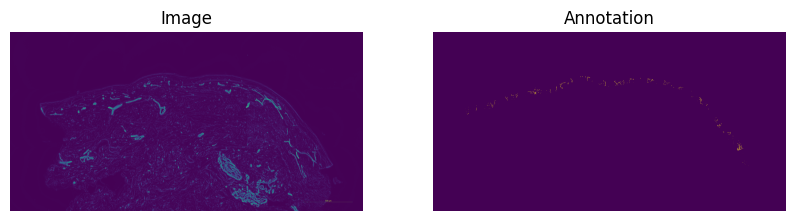

In [20]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import skimage as ski

sample_id =  "S1585-2_a"

img = np.array(Image.open(f"../data/{IMAGE_ID}/image.png"))[:,:,1]
annotation = np.array(Image.open(f"../data/{IMAGE_ID}/annotation.png").convert("L")).astype(np.uint8)

bg_small = ski.restoration.rolling_ball(img, radius=10)
bg_tiny = ski.restoration.rolling_ball(img, radius=4)
bg = np.minimum(bg_small, bg_tiny)

fg_img = (img.astype(np.uint8) - bg.astype(np.uint8)).astype(np.uint8)


_, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(fg_img)
ax[0].set_title("Image")
ax[0].axis('off')

ax[1].imshow(annotation)
ax[1].set_title("Annotation")
ax[1].axis('off')
plt.show()

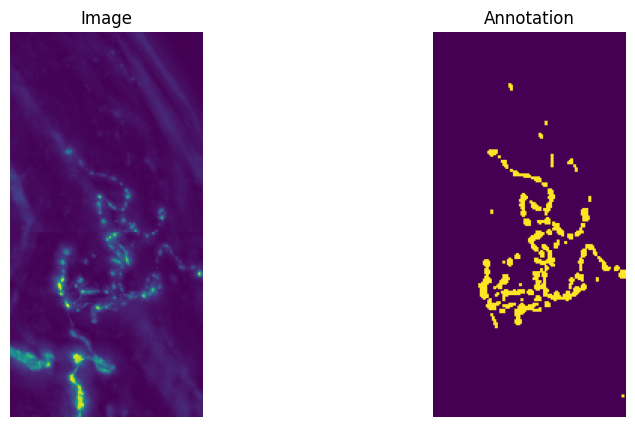

In [21]:

roi = fg_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W]
roi_annotation = annotation[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W]
# roi = fg_img
# roi_annotation = annotation

_, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(roi)
ax[0].set_title("Image")
ax[0].axis('off')

ax[1].imshow(roi_annotation)
ax[1].set_title("Annotation")
ax[1].axis('off')
plt.show()

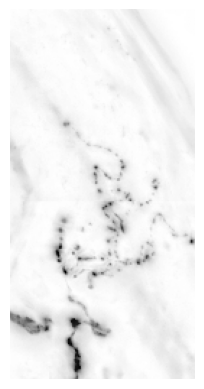

In [22]:
cost_map = roi.astype(np.float32)
cost_map = (255 - cost_map) / 255.0

plt.imshow(cost_map, cmap='gray')
plt.axis('off')
plt.show()

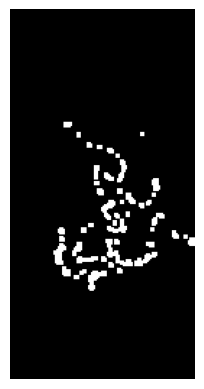

In [23]:
import cv2

opening_notation = roi_annotation.copy()
opening_notation[opening_notation > 0] = 255

opening_notation = cv2.morphologyEx(opening_notation, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

plt.imshow(opening_notation, cmap='gray')
plt.axis('off')
plt.show()

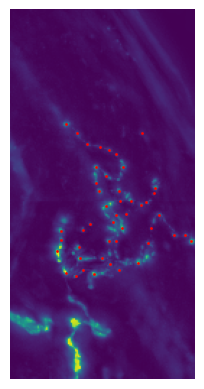

In [24]:
from typing import Tuple, Dict, Optional, List

notation_components = cv2.connectedComponentsWithStats(opening_notation, connectivity=4)

seed_points: List[Tuple[int, int]] = []
for i in range(1, notation_components[0]):
    # Find the highest intensity point in each component
    component_mask = (notation_components[1] == i)
    ys, xs = np.where(component_mask)
    intensities = roi[ys, xs]
    max_idx = np.argmax(intensities)
    x = xs[max_idx]
    y = ys[max_idx]
    seed_points.append((y, x))  # (row, col) format


plt.imshow(roi)
for (y, x) in seed_points:
    plt.plot(x, y, 'ro', markersize=1)
plt.axis('off')
plt.show()

In [25]:
from typing import Tuple, List, Deque
from collections import deque
import heapq

l_bk = 10
alpha = 0.8
eta = 1e-3
l_AVE = 1000
l_E = 1500
P = (255 - roi.astype(np.float64)) ** 4 / (255 ** 4)

def mppbt(seed):
        # seed = seed_points[3]  # Using the first seed point for demonstration
    NS_min = 5e-2
    rows, cols = P.shape
    I_BK = np.zeros((rows, cols), dtype=np.float64)  # Feature map for accumulation
    U = np.full((rows, cols), np.inf, dtype=np.float64)  # Accumulated cost
    U[seed] = 0.0

    parent: Dict[Tuple[int, int], Tuple[int, int]] = {}
    visited = np.zeros((rows, cols), dtype=bool)

    # Priority queue for Dijkstra
    heap = [(0.0, seed[0], seed[1])]

    # Stopping criterion variables
    l_SM = 0
    stop_propagation = False

    # For computing NS: store recent S values
    S_values: Deque[float] = deque(maxlen=l_AVE)
    S_max = 0.0


    iteration = 0
    min_points_before_stopping = 100  # Don't check stopping until we have enough points
    neighbors = [
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1),          (0, 1),
    (1, -1),  (1, 0), (1, 1)
    ]
    neighbor_distances = np.array([
    np.sqrt(2), 1.0, np.sqrt(2),
    1.0,              1.0,
    np.sqrt(2), 1.0, np.sqrt(2)
    ])

    global_min_NS = 1.0
    NS_record = []
    reached_order = []
    while heap and not stop_propagation:
        # Get next point with minimum cost
        current_cost, r, c = heapq.heappop(heap)
        p = (r, c)
        
        if visited[p]:
            continue
        
        visited[p] = True
        reached_order.append(p)
        iteration += 1
        
        # ----- IMMEDIATELY backtrack from current point p -----
        backtrack_path = []
        current = p
        steps = 0
        
        while steps < l_bk and current != seed and current in parent:
            backtrack_path.append(current)
            current = parent[current]
            steps += 1
        
        if current != p or len(backtrack_path) == 0:
            backtrack_path.append(current)
        
        # Get p_bk^E (the last point in backtracking path)
        p_bk_E = backtrack_path[-1]
        
        # ----- IMMEDIATELY accumulate evidence at p_bk^E -----
        # Eq. (3): I_BK(p_bk^E) += 1 / (η + P(p_bk^E))
        I_BK[p_bk_E] += 1.0 / (eta + P[p_bk_E])
        
        # ----- COST RESETTING SCHEME -----
        # Key mechanism to solve shortcut and accumulation problems!
        # Reset U(p) to the cost difference between p and p_bk^E
        # This makes the cost represent "distance from nearest feature point"
        # instead of "distance from starting point"
        segment_cost = 0.0
        for i in range(len(backtrack_path) - 1):
            p_curr = backtrack_path[i]
            p_next = backtrack_path[i + 1]  # Parent (closer to p_s)
            # Euclidean distance between adjacent points (1.0 or sqrt(2))
            dist = np.sqrt((p_curr[0] - p_next[0])**2 + (p_curr[1] - p_next[1])**2)
            # Cost contribution: P(current point) * distance
            segment_cost += P[p_curr] * dist
        
        # Ensure U_reset is positive (can be zero or negative if p == p_bk^E)
        U_reset = max(segment_cost, eta)
        U[p] = U_reset
        
        # ----- IMMEDIATELY calculate Backtracking Speed S(p) -----
        # Eq. (4): S(p) = l_bk / (U(p) - U(p_bk^E))
        # After reset, this is simply: S(p) = actual_steps / U_reset
        actual_steps = len(backtrack_path) - 1 if len(backtrack_path) > 1 else 1
        
        # After cost resetting, U[p] is already the cost from p_bk^E to p
        # So S(p) = actual_steps / U[p] (which is U_reset)
        cost_diff = U_reset  # This is U(p) - U(p_bk^E)
        
        # Skip S/NS calculation for points too close to start
        if cost_diff > eta and actual_steps > 0:
            S_p = actual_steps / cost_diff
        else:
            S_p = 0  # Will be skipped in NS calculation
        
        # Only update S_max and S_values for valid S values
        if S_p > 0:
            if S_max == 0 or S_p > S_max:
                S_max = S_p
            S_values.append(S_p)
        
        # ----- IMMEDIATELY calculate Normalized Average Speed NS(p) -----
        # Eq. (5): NS(p) = S_bar(p, l_AVE) / S_max(p)
        # Only check stopping after we have enough valid S values
        if len(S_values) >= min_points_before_stopping and S_max > 0:
            S_bar = sum(S_values) / len(S_values)
            NS_p = S_bar / S_max
            NS_record.append(NS_p)
            if NS_p < global_min_NS:
                global_min_NS = NS_p
            # ----- IMMEDIATELY check Stopping Criterion -----
            if NS_p < NS_min:
                l_SM += 1
            else:
                l_SM = 0
                
            NS_min = global_min_NS  # Update to current minimum
            
            if l_SM >= l_E:
                stop_propagation = True
                print(f"  Stopping at iteration {iteration}: l_SM={l_SM} >= l_E={l_E}")
        else:
            NS_p = 1.0  # Default value before we have enough data
        
        # ----- Expand neighbors (Dijkstra step) -----
        if not stop_propagation:
            for i, (dr, dc) in enumerate(neighbors):
                nr, nc = r + dr, c + dc
                
                if not (0 <= nr < rows and 0 <= nc < cols):
                    continue
                if visited[nr, nc]:
                    continue
                
                step_cost = P[nr, nc] * neighbor_distances[i]
                new_cost = U[p] + step_cost
                
                if new_cost < U[nr, nc]:
                    U[nr, nc] = new_cost
                    parent[(nr, nc)] = p
                    heapq.heappush(heap, (new_cost, nr, nc))
        
    I_BK_alpha = np.quantile(I_BK[I_BK > 0], alpha)
    I_C = (I_BK > I_BK_alpha).astype(np.uint8)
        # print(f"  Iter {iteration}: NS={NS_p:.4f}, NS_min={NS_min:.4f}, l_SM={l_SM}")
    I_C_refined = I_C.copy()
    for p in zip(*np.where(I_BK > 0)):
        backtrack_path = []
        current = p
        steps = 0
        
        while steps < l_bk and current in parent and current != seed:
            # if current in :
            #     break
            
            backtrack_path.append(current)
            current = parent[current]
            steps += 1
        
        if current != p:
            backtrack_path.append(current)
        
        if len(backtrack_path) > 0:
            p_bk_E = backtrack_path[-1]
            if I_C[p_bk_E] == 1:
                for pbk in backtrack_path:
                    I_C_refined[pbk] = 1
    
    return I_BK, U, I_C_refined, parent
            
            

In [28]:
# I_BKS = np.zeros((roi.shape[0], roi.shape[1]), dtype=np.float64)
I_CS = []
I_BKS = []
U_S = []
voted_parents: Dict[Tuple[int, int], Dict[Tuple[int, int], int]] = {}
for seed in seed_points[1:3]:
    print(f"Processing seed at {seed}...")
    I_BK, U, I_C_refined, parent = mppbt(seed)
    # I_CS += I_C_refined
    I_CS.append(I_C_refined)
    I_BKS.append(I_BK)
    U_S.append(U)
    # Voting for parents
    for child, par in parent.items():
        if child not in voted_parents:
            voted_parents[child] = {}
        if par not in voted_parents[child]:
            voted_parents[child][par] = 0
        voted_parents[child][par] += 1

highest_vote_parents: Dict[Tuple[int, int], Tuple[int, int]] = {}
for child, par_votes in voted_parents.items():
    highest_parent = max(par_votes.items(), key=lambda x: x[1])[0]
    highest_vote_parents[child] = highest_parent


Processing seed at (np.int64(85), np.int64(46))...
Processing seed at (np.int64(85), np.int64(91))...


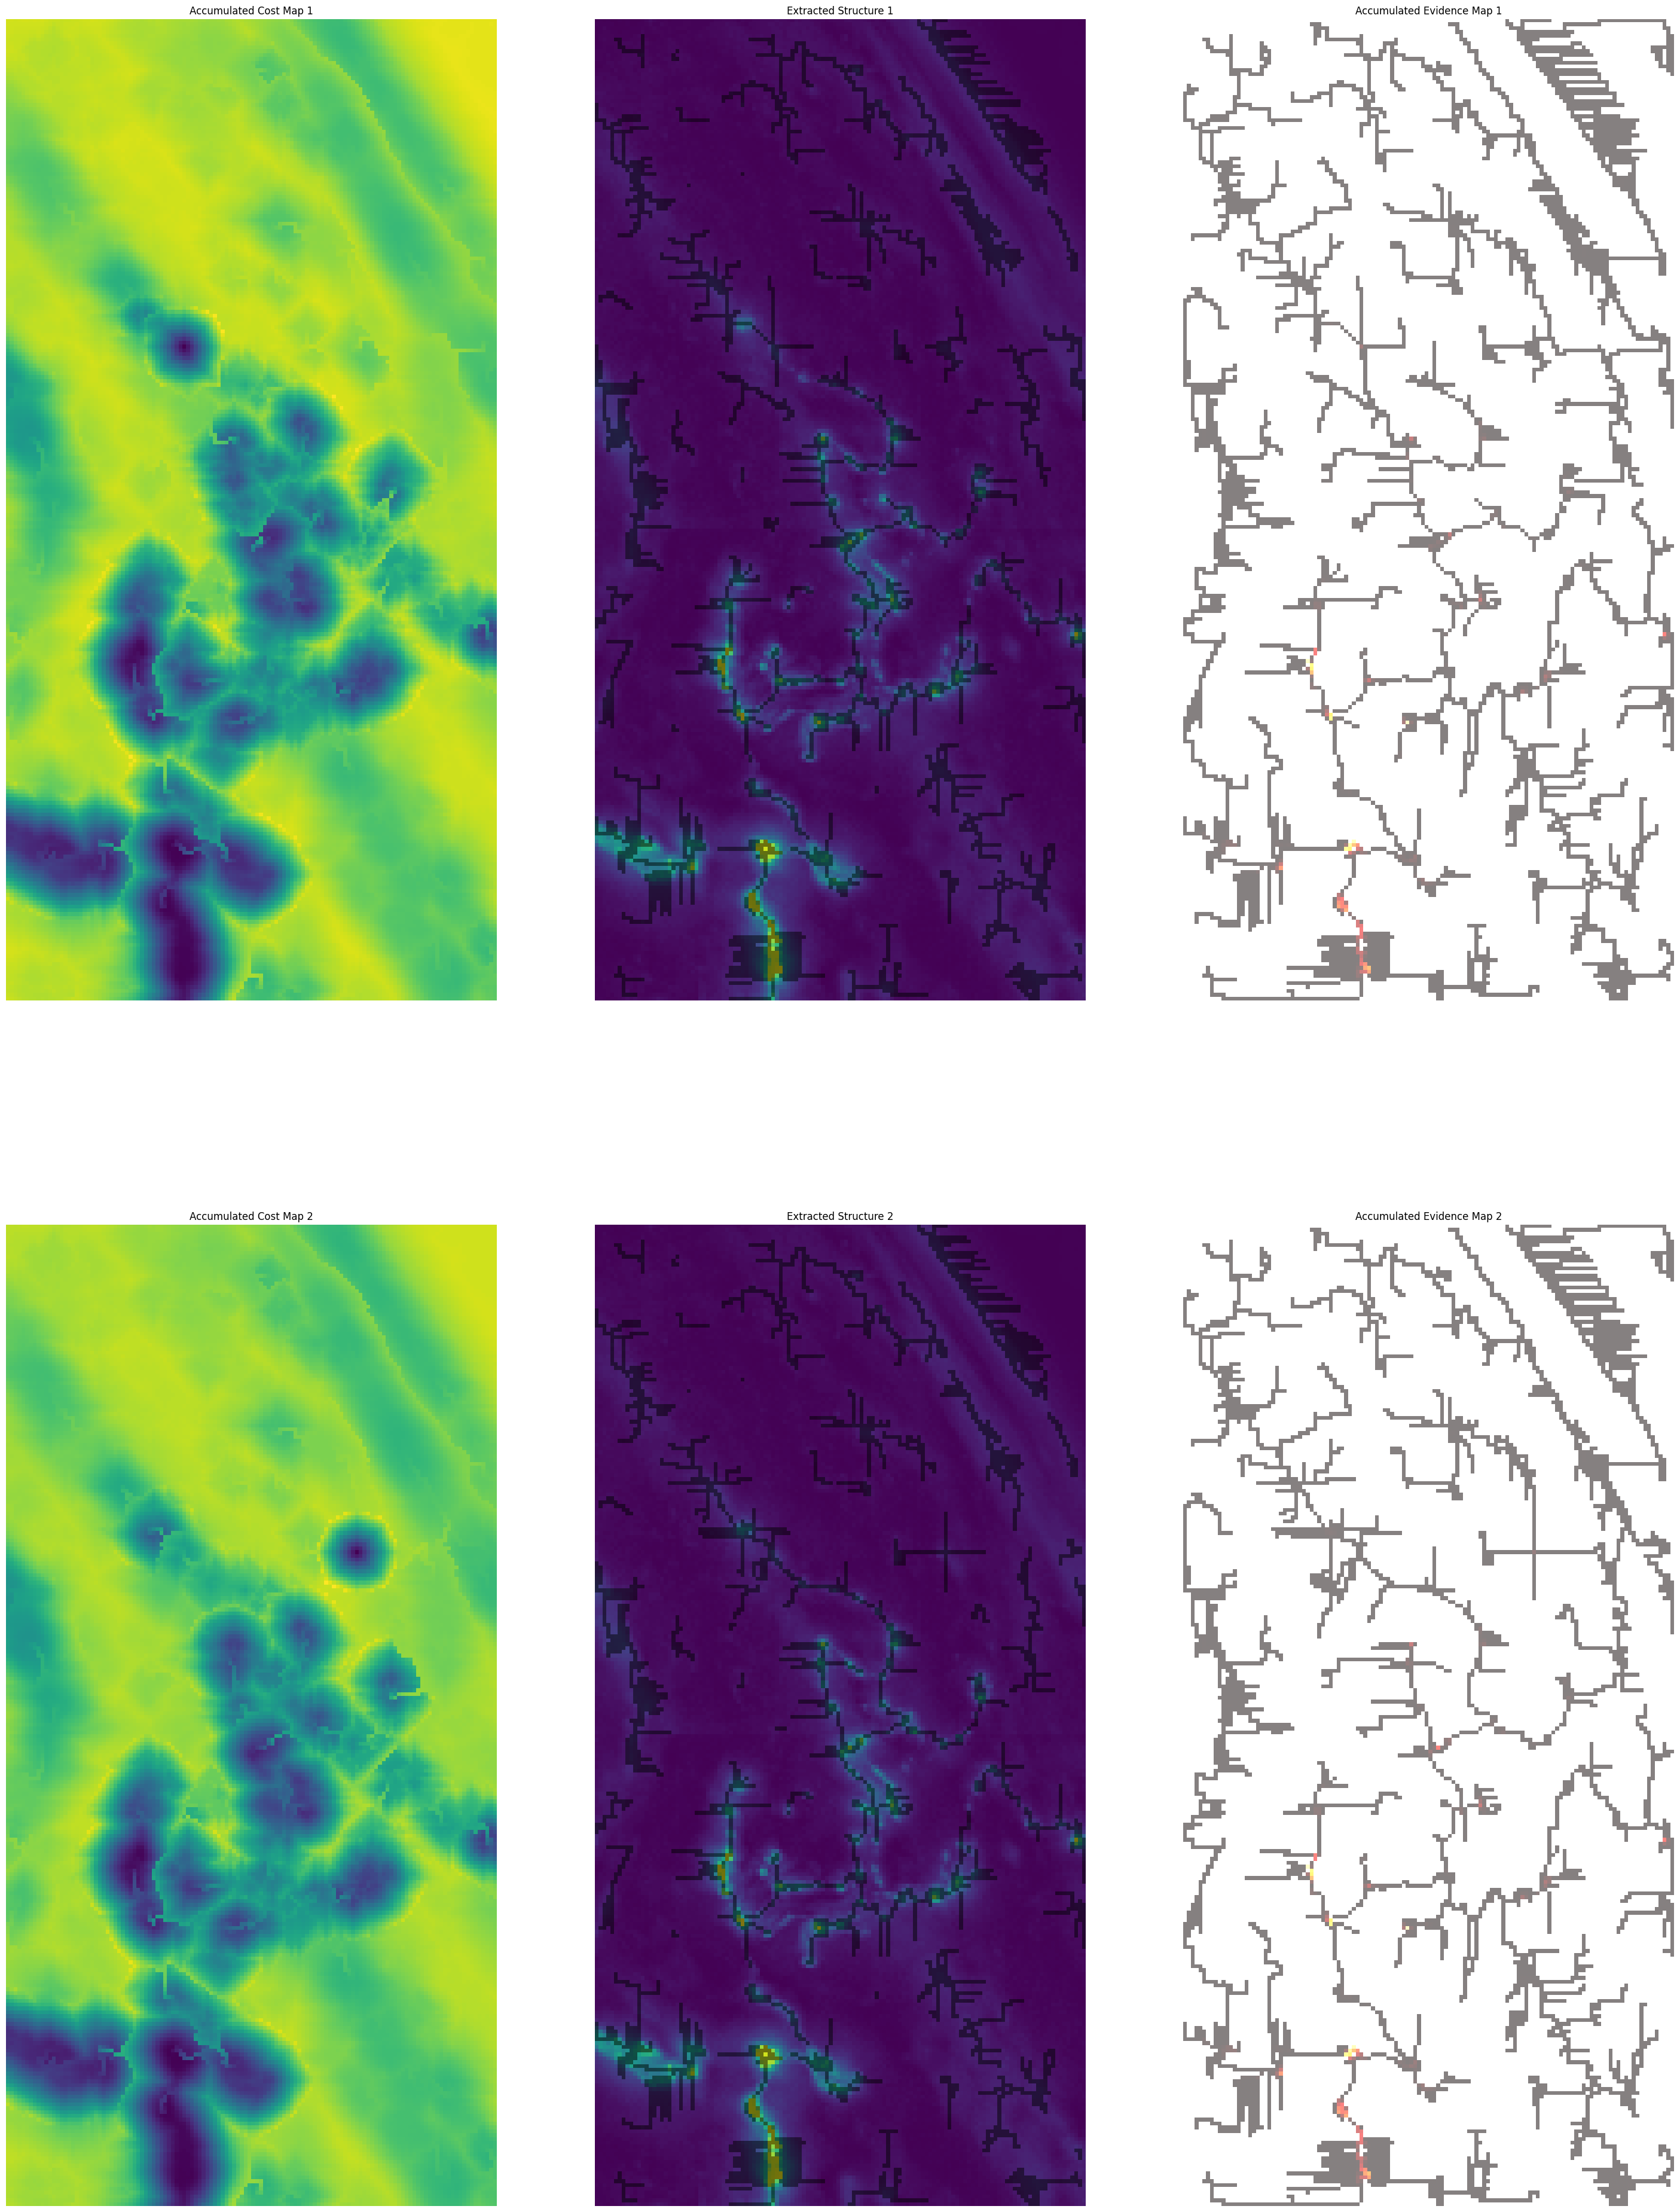

In [29]:
image_per_row = 2
h_per_image = 24 
w_per_image = 12

row_count = len(U_S)
_, ax = plt.subplots(row_count, 3, figsize=(w_per_image * 3, h_per_image * row_count))
for idx in range(row_count):
    axu = ax[idx, 0]
    axu.imshow(U_S[idx])

    axu.set_title(f"Accumulated Cost Map {idx+1}")
    axu.axis('off')
    axic = ax[idx, 1]
    axic.imshow(roi)
    axic.imshow(np.ma.masked_where(I_CS[idx] == 0, I_CS[idx]), cmap='gray', alpha=0.5)
    axic.set_title(f"Extracted Structure {idx+1}")
    axic.axis('off')


    axib = ax[idx, 2]
    # axib.imshow(roi)
    axib.imshow(np.ma.masked_where(I_BKS[idx] == 0, I_BKS[idx]), cmap='hot', alpha=0.5)
    axib.set_title(f"Accumulated Evidence Map {idx+1}")
    axib.axis('off')
plt.show()

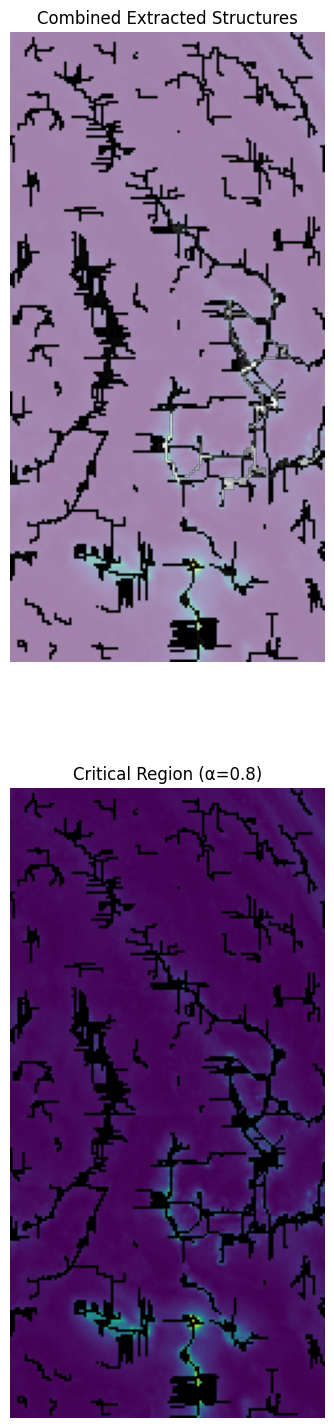

In [ ]:


_, ax = plt.subplots(2, 1, figsize=(24, 18))

IC_heatmap = np.zeros_like(roi, dtype=np.float64)
for I_BK in I_CS:
    # IC_heatmap[I_C > 0] += 1
    IC_heatmap += I_BK

axib = ax[0]
axib.imshow(roi, alpha=0.5)
axib.imshow(np.ma.masked_where(IC_heatmap == 0, IC_heatmap), cmap='gray', alpha=1)
axib.set_title("Combined Extracted Structures")
axib.axis('off')


IC_threshold = np.quantile(IC_heatmap[IC_heatmap > 0], 0.25)
I_C_combined = (IC_heatmap >= IC_threshold).astype(np.uint8)

axic = ax[1]
masked_I_C = np.ma.masked_where(I_C_combined == 0, I_C_combined)
axic.imshow(roi)
axic.imshow(masked_I_C, cmap='gray', alpha=1)
axic.set_title(f"Critical Region (α={alpha})")
axic.axis('off')

# Show reached area
# reached_area = np.zeros_like(roi, dtype=np.float32)
# reached_area[U < np.inf] = 1.0
# ax[0].imshow(U, cmap='gray')
# ax[0].set_title("Reached Area after First Propagation")
# ax[0].axis('off')
# axib = ax[0]
# axib.imshow(roi)
# axib.imshow(np.ma.masked_where(I_CS == 0, I_CS), cmap='gray', alpha=0.5)
# axib.set_title("Path Heat Map")
# axib.axis('off')

# axic = ax[1]
# masked_I_C = np.ma.masked_where(I_C_refined == 0, I_C_refined)
# axic.imshow(roi)
# axic.imshow(masked_I_C, cmap='gray', alpha=1)
# axic.set_title(f"Critical Region (α={alpha})")
# axic.axis('off')

plt.show()